In [ ]:
import pandas as pd

df = pd.read_csv("../data/processed/merged_for_eda.csv")

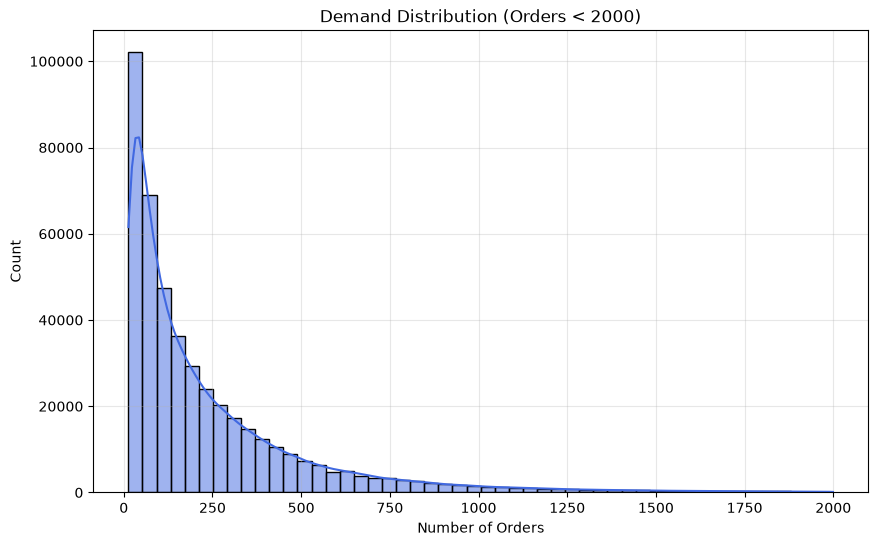

<Figure size 640x480 with 0 Axes>

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))

sns.histplot(
    df[df["num_orders"] < 2000]["num_orders"],
    bins=50,
    kde=True,
    color="royalblue"
)

plt.title("Demand Distribution (Orders < 2000)")
plt.xlabel("Number of Orders")
plt.ylabel("Count")
plt.grid(alpha=0.3)

plt.show()
plt.savefig("../reports/figures/demand_distribution.png")

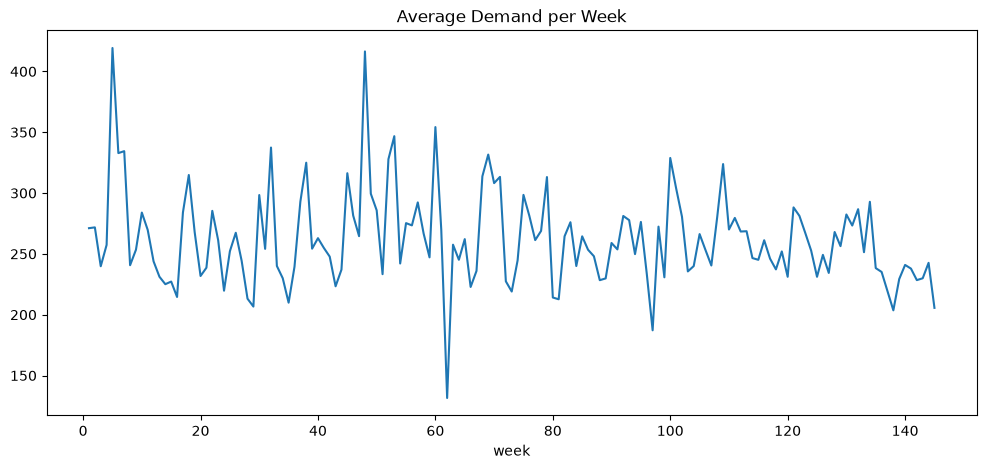

In [10]:
weekly = df.groupby("week")["num_orders"].mean()

plt.figure(figsize=(12,5))
weekly.plot()
plt.title("Average Demand per Week")
plt.savefig("../reports/figures/weekly_trend.png")

<Axes: xlabel='emailer_for_promotion', ylabel='num_orders'>

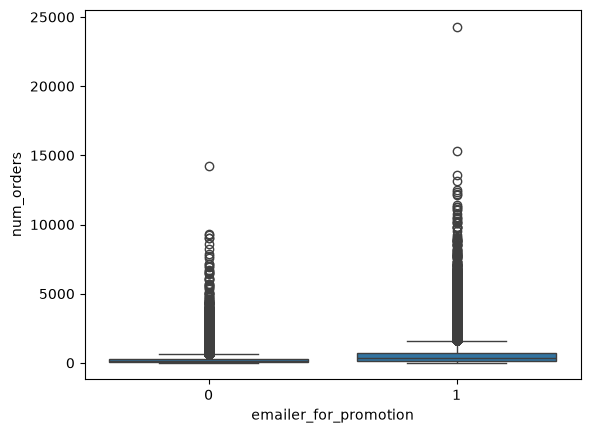

In [11]:
sns.boxplot(
    x="emailer_for_promotion",
    y="num_orders",
    data=df
)

<Axes: xlabel='homepage_featured', ylabel='num_orders'>

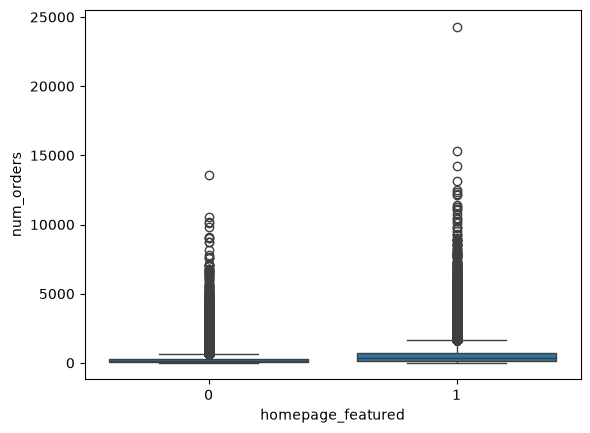

In [12]:
sns.boxplot(
    x="homepage_featured",
    y="num_orders",
    data=df
)

<Axes: xlabel='checkout_price', ylabel='num_orders'>

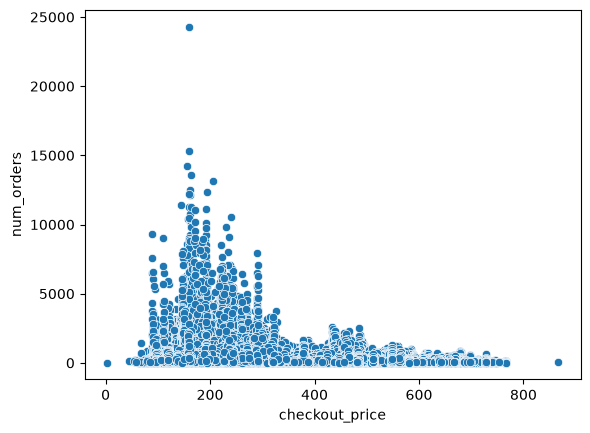

In [13]:
sns.scatterplot(
    x="checkout_price",
    y="num_orders",
    data=df
)

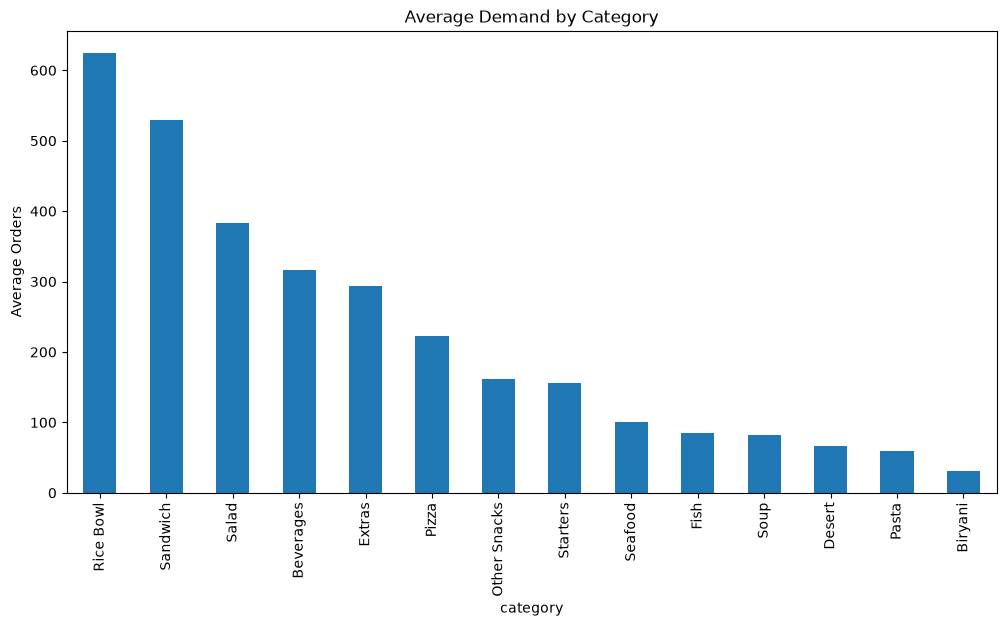

In [15]:
category_demand = (
    df.groupby("category")["num_orders"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
category_demand.plot(kind="bar")
plt.title("Average Demand by Category")
plt.ylabel("Average Orders")
plt.show()

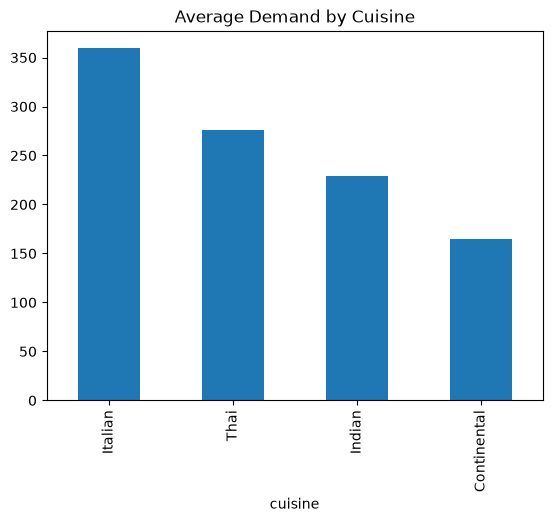

In [16]:
cuisine_demand = (
    df.groupby("cuisine")["num_orders"]
    .mean()
    .sort_values(ascending=False)
)

cuisine_demand.plot(kind="bar")
plt.title("Average Demand by Cuisine")
plt.show()

<Axes: xlabel='center_type'>

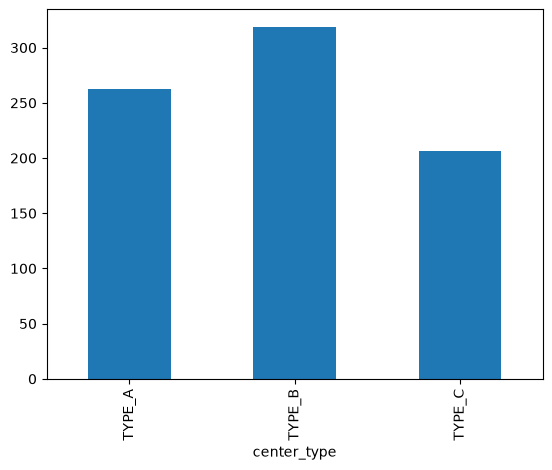

In [17]:
center_type = (
    df.groupby("center_type")["num_orders"]
    .mean()
)

center_type.plot(kind="bar")

<Axes: xlabel='region_code'>

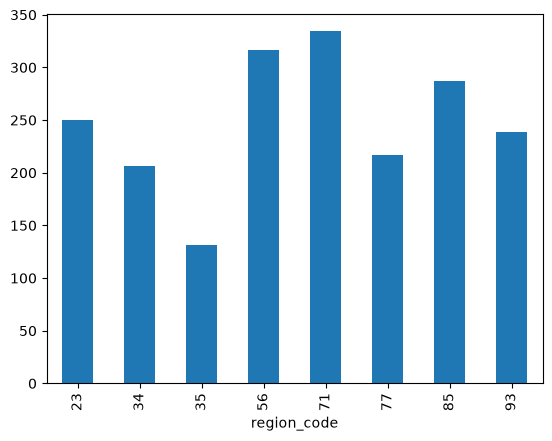

In [18]:
region = (
    df.groupby("region_code")["num_orders"]
    .mean()
)

region.plot(kind="bar")

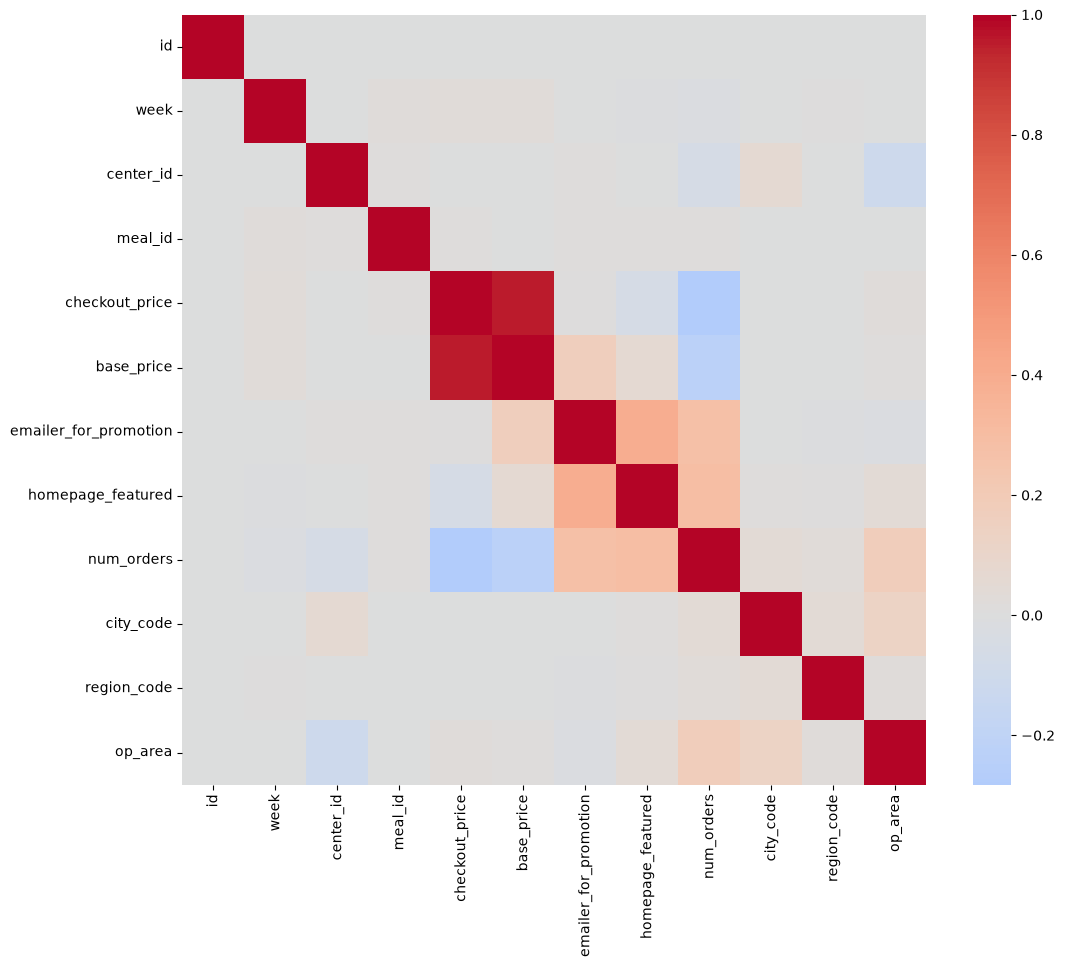

In [19]:
numeric = df.select_dtypes(include="number")

plt.figure(figsize=(12,10))
sns.heatmap(
    numeric.corr(),
    cmap="coolwarm",
    center=0
)
plt.show()